# EDA


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
data_path = "../data/raw/data.csv"
events_path = "../data/raw/events.csv"

data_df = pd.read_csv(data_path)
events_df = pd.read_csv(events_path)

In [4]:
print(data_df.columns)
print(events_df.columns)

Index(['order_id', 'user_id', 'status', 'gender', 'created_at', 'returned_at',
       'shipped_at', 'delivered_at', 'num_of_item', 'product_id',
       'inventory_item_id', 'sale_price', 'id', 'first_name', 'last_name',
       'email', 'age', 'state', 'street_address', 'postal_code', 'city',
       'country', 'traffic_source', 'user_geom', 'cost', 'category', 'brand',
       'retail_price', 'department', 'sku', 'distribution_center_id',
       'sold_at', 'product_category', 'product_name', 'product_brand',
       'product_retail_price', 'product_department', 'product_sku',
       'product_distribution_center_id', 'distribution_center_geom',
       'order_item_id', 'delivery_longitude', 'delivery_latitude',
       'warehouse_name', 'warehouse_longitude', 'warehouse_latitude',
       'is_loyal', 'product_name_clean', 'customer_review'],
      dtype='str')
Index(['id', 'user_id', 'sequence_number', 'session_id', 'created_at',
       'ip_address', 'city', 'state', 'postal_code', 'browser',

In [5]:
# Размеры
print(data_df.shape, events_df.shape)

# Типы данных
print(data_df.dtypes)
print(events_df.dtypes)

# Пропуски
print(data_df.isnull().sum().sort_values(ascending=False).head(10))
print(events_df.isnull().sum().sort_values(ascending=False).head(10))

# Уникальные значения в ключевых полях
print(data_df['status'].unique())
print(events_df['event_type'].unique())

(545778, 49) (4865324, 13)
order_id                            int64
user_id                             int64
status                                str
gender                                str
created_at                            str
returned_at                           str
shipped_at                            str
delivered_at                          str
num_of_item                         int64
product_id                          int64
inventory_item_id                   int64
sale_price                        float64
id                                  int64
first_name                            str
last_name                             str
email                                 str
age                                 int64
state                                 str
street_address                        str
postal_code                           str
city                                  str
country                               str
traffic_source                        str
user_ge

In [6]:
import pandas as pd

# Дата-поля в data_df
date_cols_data = ['created_at', 'returned_at', 'shipped_at', 'delivered_at']
for col in date_cols_data:
    data_df[col] = pd.to_datetime(data_df[col], errors='coerce')

# Дата-поля в events_df
events_df['created_at'] = pd.to_datetime(events_df['created_at'], errors='coerce')

# Числовые (проверить, что не стали object)
numeric_cols = ['sale_price', 'retail_price', 'cost', 'age', 'num_of_item']
for col in numeric_cols:
    data_df[col] = pd.to_numeric(data_df[col], errors='coerce')

In [7]:
# 1. events_df — убираем строки без user_id (они бесполезны для модели)
events_df_clean = events_df[events_df['user_id'].notna()].copy()
events_df_clean['user_id'] = events_df_clean['user_id'].astype(int)

print(f"Было: {len(events_df):,}, стало: {len(events_df_clean):,}")

# 2. data_df — создаём флаги для пропусков (полезно для модели)
data_df['is_returned'] = data_df['returned_at'].notna().astype(int)
data_df['is_delivered'] = data_df['delivered_at'].notna().astype(int)

# 3. Заполняем пропуски в доставке (для расчёта сроков)
# Если доставлен, но нет даты — берём shipped_at + 3 дня
mask_delivered = (data_df['status'] == 'Complete') & (data_df['delivered_at'].isna())
data_df.loc[mask_delivered, 'delivered_at'] = data_df.loc[mask_delivered, 'shipped_at'] + pd.Timedelta(days=3)

# 4. customer_review — заполняем 0 (нет отзыва)
data_df['customer_review'] = data_df['customer_review'].fillna(0)

# 5. age — медиана по полу
data_df['age'] = data_df.groupby('gender')['age'].transform(lambda x: x.fillna(x.median()))


Было: 4,865,324, стало: 2,616,836


In [8]:
# Отрезаем экстремальные цены (1% и 99% перцентили)
q1 = data_df['sale_price'].quantile(0.01)
q99 = data_df['sale_price'].quantile(0.99)
data_df = data_df[(data_df['sale_price'] >= q1) & (data_df['sale_price'] <= q99)]

print(f"После удаления выбросов: {len(data_df):,} строк")

После удаления выбросов: 534,993 строк


In [9]:
# Для расчёта RFM и LTV берём только Complete (доставленные и оплаченные)
completed_orders = data_df[data_df['status'] == 'Complete'].copy()
print(f"Завершённых заказов: {len(completed_orders):,}")

Завершённых заказов: 133,311


In [10]:
# Текущая дата для расчёта recency
current_date = completed_orders['created_at'].max() + pd.Timedelta(days=1)

# RFM по пользователям
rfm = completed_orders.groupby('user_id').agg(
    recency=('created_at', lambda x: (current_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('sale_price', 'sum')
).reset_index()

# RFM-скоры (квартили)
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4, 3, 2, 1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1, 2, 3, 4])

# Итоговый сегмент
rfm['RFM_segment'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

print(rfm.head())
print(f"Уникальных пользователей в RFM: {len(rfm)}")

   user_id  recency  frequency    monetary R_score F_score M_score RFM_segment
0        1    513.0          1  166.470005       2       1       2       2.012
1        2    334.0          1  372.000000       3       1       3       3.013
2       12      1.0          1   41.250000       4       1       1       4.011
3       14    258.0          2  230.939999       3       4       3       3.043
4       17   1273.0          1  254.849991       1       1       3       1.013
Уникальных пользователей в RFM: 27151


In [11]:
# Считаем возвраты на пользователя (по всей data_df, не только Complete)
returns = data_df.groupby('user_id').agg(
    total_orders_all=('order_id', 'nunique'),
    returns_count=('returned_at', lambda x: x.notna().sum())
).reset_index()

returns['return_rate'] = returns['returns_count'] / returns['total_orders_all']
returns['return_rate'] = returns['return_rate'].fillna(0)

print(returns.head())

   user_id  total_orders_all  returns_count  return_rate
0        1                 1              0          0.0
1        2                 2              0          0.0
2        3                 1              6          6.0
3        4                 1              0          0.0
4        6                 1              0          0.0


In [12]:
# Создаём копию с доставленными заказами
delivered_orders = data_df[data_df['delivered_at'].notna() & data_df['shipped_at'].notna()].copy()

# Считаем дни доставки
delivered_orders['delivery_days'] = (delivered_orders['delivered_at'] - delivered_orders['shipped_at']).dt.days

# Агрегация по пользователю
delivery_agg = delivered_orders.groupby('user_id')['delivery_days'].agg(
    avg_delivery_days='mean',
    max_delivery_days='max',
    std_delivery_days='std'
).reset_index()

# Заполняем пропуски (у кого не было доставленных заказов)
delivery_agg['avg_delivery_days'] = delivery_agg['avg_delivery_days'].fillna(7)  # среднее по рынку
delivery_agg['max_delivery_days'] = delivery_agg['max_delivery_days'].fillna(14)
delivery_agg['std_delivery_days'] = delivery_agg['std_delivery_days'].fillna(0)

print(delivery_agg.head())

   user_id  avg_delivery_days  max_delivery_days  std_delivery_days
0        1                3.0                  3                0.0
1        2                3.0                  3                0.0
2       12                3.0                  3                0.0
3       14                3.0                  3                0.0
4       17                3.0                  3                0.0


In [13]:
# Агрегация событий по пользователю
events_agg = events_df_clean.groupby('user_id').agg(
    total_events=('event_type', 'count'),
    unique_sessions=('session_id', 'nunique'),
    last_event_date=('created_at', 'max')
).reset_index()

# Считаем дни с последнего события
events_agg['days_since_last_event'] = (current_date - events_agg['last_event_date']).dt.days

# Считаем отдельно типы событий (если нужно для модели)
event_types = events_df_clean.groupby(['user_id', 'event_type']).size().unstack(fill_value=0).reset_index()
event_types.columns = ['user_id'] + [f'event_{col}' for col in event_types.columns[1:]]

# Объединяем
events_agg = events_agg.merge(event_types, on='user_id', how='left')

# Заполняем пропуски
events_agg['total_events'] = events_agg['total_events'].fillna(0)
events_agg['unique_sessions'] = events_agg['unique_sessions'].fillna(0)
events_agg['days_since_last_event'] = events_agg['days_since_last_event'].fillna(999)  # очень давно

for col in event_types.columns[1:]:
    events_agg[col] = events_agg[col].fillna(0)

print(events_agg.head())
print(f"Уникальных пользователей в events: {len(events_agg)}")

   user_id  total_events  unique_sessions           last_event_date  \
0        1            10                1 2024-10-14 10:19:27+00:00   
1        2            56                4 2025-04-14 11:54:55+00:00   
2        3            28                2 2022-09-09 18:30:48+00:00   
3        4            10                1 2026-02-28 05:16:10+00:00   
4        6            10                1 2024-03-04 09:09:51+00:00   

   days_since_last_event  event_cart  event_department  event_home  \
0                  513.0           2                 2           2   
1                  331.0          16                16           0   
2                 1279.0           8                 8           0   
3                   11.0           2                 2           2   
4                  737.0           2                 2           2   

   event_product  event_purchase  
0              2               2  
1             16               8  
2              8               4  
3           

In [14]:
# Берём одного пользователя — одну строку
demo = data_df[['user_id', 'age', 'gender', 'is_loyal', 'traffic_source', 'state', 'city']].drop_duplicates('user_id')

# Заполняем возраст (если остались пропуски)
demo['age'] = demo['age'].fillna(demo['age'].median())
demo['gender'] = demo['gender'].fillna('Unknown')

print(demo.head())
print(f"Уникальных пользователей в демографии: {len(demo)}")

   user_id  age gender  is_loyal traffic_source          state        city
0    94911   43      F     False          Email       Arkansas  Pine Bluff
1    91961   18      M     False         Search     California       Selma
3    79993   26      F     False         Search        Beijing     Tieling
4    74352   68      M     False         Search  Île-de-France     Gonesse
5    78101   35      M     False         Search       Zhejiang     Nanjing
Уникальных пользователей в демографии: 79357


In [15]:
# Начинаем с RFM (база)
features = rfm.copy()

# Добавляем возвраты
features = features.merge(returns[['user_id', 'return_rate', 'returns_count', 'total_orders_all']], on='user_id', how='left')

# Добавляем доставку
features = features.merge(delivery_agg, on='user_id', how='left')

# Добавляем события
features = features.merge(events_agg, on='user_id', how='left')

# Добавляем демографию
features = features.merge(demo, on='user_id', how='left')

# Заполняем все оставшиеся пропуски
features['return_rate'] = features['return_rate'].fillna(0)
features['returns_count'] = features['returns_count'].fillna(0)
features['total_orders_all'] = features['total_orders_all'].fillna(0)
features['avg_delivery_days'] = features['avg_delivery_days'].fillna(7)
features['max_delivery_days'] = features['max_delivery_days'].fillna(14)
features['std_delivery_days'] = features['std_delivery_days'].fillna(0)
features['total_events'] = features['total_events'].fillna(0)
features['unique_sessions'] = features['unique_sessions'].fillna(0)
features['days_since_last_event'] = features['days_since_last_event'].fillna(999)

print(features.shape)
print(features.head(3))

(27151, 29)
   user_id  recency  frequency    monetary R_score F_score M_score  \
0        1    513.0          1  166.470005       2       1       2   
1        2    334.0          1  372.000000       3       1       3   
2       12      1.0          1   41.250000       4       1       1   

  RFM_segment  return_rate  returns_count  ...  event_department  event_home  \
0       2.012          0.0              0  ...                 2           2   
1       3.013          0.0              0  ...                16           0   
2       4.011          0.0              0  ...                 2           2   

   event_product  event_purchase  age  gender is_loyal  traffic_source  \
0              2               2   40       M    False          Search   
1             16               8   46       F     True          Search   
2              2               2   16       M    False         Organic   

          state       city  
0          Iowa  Davenport  
1  Dolnośląskie  Bogatynia  
2 

In [16]:
# Продажи по товарам (только Complete)
product_sales = completed_orders.groupby('product_id').agg(
    total_revenue=('sale_price', 'sum'),
    total_quantity=('num_of_item', 'sum'),
    order_count=('order_id', 'nunique')
).reset_index()

# Сортируем по выручке и считаем кумулятивный процент
product_sales = product_sales.sort_values('total_revenue', ascending=False)
product_sales['cumulative_revenue'] = product_sales['total_revenue'].cumsum()
product_sales['cumulative_percent'] = product_sales['cumulative_revenue'] / product_sales['total_revenue'].sum() * 100

# Присваиваем классы
def abc_class(percent):
    if percent <= 80:
        return 'A'
    elif percent <= 95:
        return 'B'
    else:
        return 'C'

product_sales['ABC_class'] = product_sales['cumulative_percent'].apply(abc_class)

print(product_sales.head(10))
print(f"\nРаспределение: \n{product_sales['ABC_class'].value_counts()}")

       product_id  total_revenue  total_quantity  order_count  \
18527       24325    5688.000000              30            8   
15244       20233    4679.819824              42            6   
20630       26929    4499.250183              30            5   
20549       26823    4185.000000              36            5   
14307       19061    4176.000000              39            6   
5760         7761    4170.000000              33            5   
11829       16045    3948.000000              51            7   
6223         8383    3900.000000              36            8   
6171         8313    3881.250000              18            5   
20699       27012    3675.000000              36            5   

       cumulative_revenue  cumulative_percent ABC_class  
18527         5688.000000            0.075960         A  
15244        10367.819824            0.138456         A  
20630        14867.070007            0.198541         A  
20549        19052.070007            0.254429       

In [17]:
# Все уникальные user_id из исходной data_df
all_users = data_df[['user_id']].drop_duplicates()

# Все уникальные user_id из events
all_users_events = events_df_clean[['user_id']].drop_duplicates()

# Объединяем всех возможных пользователей
all_users_total = pd.concat([all_users, all_users_events]).drop_duplicates()
print(f"Всего уникальных пользователей в системе: {len(all_users_total)}")

# Создаём features_full с левым джойном от всех пользователей
features_full = all_users_total.merge(features, on='user_id', how='left')

# Заполняем пропуски для пользователей без покупок
features_full['recency'] = features_full['recency'].fillna(999)  # очень давно
features_full['frequency'] = features_full['frequency'].fillna(0)
features_full['monetary'] = features_full['monetary'].fillna(0)
features_full['R_score'] = features_full['R_score'].fillna(1)  # худший
features_full['F_score'] = features_full['F_score'].fillna(1)
features_full['M_score'] = features_full['M_score'].fillna(1)
features_full['RFM_segment'] = features_full['RFM_segment'].fillna('1.1.1')
features_full['return_rate'] = features_full['return_rate'].fillna(0)
features_full['returns_count'] = features_full['returns_count'].fillna(0)
features_full['total_orders_all'] = features_full['total_orders_all'].fillna(0)
features_full['avg_delivery_days'] = features_full['avg_delivery_days'].fillna(7)
features_full['max_delivery_days'] = features_full['max_delivery_days'].fillna(14)
features_full['std_delivery_days'] = features_full['std_delivery_days'].fillna(0)
features_full['total_events'] = features_full['total_events'].fillna(0)
features_full['unique_sessions'] = features_full['unique_sessions'].fillna(0)
features_full['days_since_last_event'] = features_full['days_since_last_event'].fillna(999)

# Событийные колонки
event_cols = [col for col in features.columns if col.startswith('event_')]
for col in event_cols:
    if col in features_full.columns:
        features_full[col] = features_full[col].fillna(0)
    else:
        features_full[col] = 0

# Демография (оставляем как есть, пропуски заполним)
demo_full = all_users_total.merge(demo, on='user_id', how='left')
demo_full['age'] = demo_full['age'].fillna(demo_full['age'].median())
demo_full['gender'] = demo_full['gender'].fillna('Unknown')
demo_full['is_loyal'] = demo_full['is_loyal'].fillna(False)
demo_full['traffic_source'] = demo_full['traffic_source'].fillna('Unknown')
demo_full['state'] = demo_full['state'].fillna('Unknown')
demo_full['city'] = demo_full['city'].fillna('Unknown')

# Обновляем features_full демографией
for col in ['age', 'gender', 'is_loyal', 'traffic_source', 'state', 'city']:
    if col in demo_full.columns:
        features_full[col] = demo_full[col]

print(f"Итоговый размер features_full: {features_full.shape}")
print(f"Из них без покупок (frequency = 0): {(features_full['frequency'] == 0).sum()}")

Всего уникальных пользователей в системе: 80021
Итоговый размер features_full: (80021, 29)
Из них без покупок (frequency = 0): 52870


In [18]:
# Определяем отток: нет покупок за последние N дней
# Возьмём порог 90 дней (стандарт для e-commerce)
current_date = completed_orders['created_at'].max() + pd.Timedelta(days=1)

# Для пользователей с покупками
features_full['last_purchase_days'] = features_full['recency']  # уже есть

# Для пользователей без покупок — считаем с момента первого события
# Если нет ни покупок, ни событий — считаем с момента регистрации (если есть)
features_full['last_activity_days'] = features_full[['recency', 'days_since_last_event']].min(axis=1)

# Отток: если last_activity_days > 90 И нет покупок за последние 90 дней
features_full['churn'] = ((features_full['last_activity_days'] > 90) & (features_full['frequency'] == 0)) | \
                         ((features_full['recency'] > 90) & (features_full['frequency'] > 0))

features_full['churn'] = features_full['churn'].astype(int)

print(f"Доля оттока: {features_full['churn'].mean():.2%}")
print(f"Отток: {features_full['churn'].sum():,} / {len(features_full):,}")

Доля оттока: 94.66%
Отток: 75,745 / 80,021


In [19]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# Копируем данные
df_model = features_full.copy()

# Выбираем признаки для модели
feature_cols = [
    'recency', 'frequency', 'monetary',
    'return_rate', 'returns_count', 'total_orders_all',
    'avg_delivery_days', 'max_delivery_days', 'std_delivery_days',
    'total_events', 'unique_sessions', 'days_since_last_event',
    'event_cart', 'event_department', 'event_home', 'event_product', 'event_purchase',
    'age', 'is_loyal'
]

# Категориальные признаки (кодируем)
categorical_cols = ['gender', 'traffic_source']

# Проверяем, какие колонки есть в df_model
available_features = [col for col in feature_cols if col in df_model.columns]
print(f"Доступные признаки: {available_features}")
print(f"Всего признаков: {len(available_features)}")

# Кодируем категориальные
label_encoders = {}
for col in categorical_cols:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('Unknown')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le
        available_features.append(col)

# Целевая переменная
X = df_model[available_features]
y = df_model['churn']

print(f"Размер X: {X.shape}")
print(f"Доля оттока: {y.mean():.2%}")

Доступные признаки: ['recency', 'frequency', 'monetary', 'return_rate', 'returns_count', 'total_orders_all', 'avg_delivery_days', 'max_delivery_days', 'std_delivery_days', 'total_events', 'unique_sessions', 'days_since_last_event', 'event_cart', 'event_department', 'event_home', 'event_product', 'event_purchase', 'age', 'is_loyal']
Всего признаков: 19
Размер X: (80021, 21)
Доля оттока: 94.66%


In [21]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import pandas as pd

# Копируем данные
df_model = features_full.copy()

# ✅ ФИКС: преобразуем is_loyal в int
df_model['is_loyal'] = df_model['is_loyal'].astype(int)

# Выбираем признаки для модели
feature_cols = [
    'recency', 'frequency', 'monetary',
    'return_rate', 'returns_count', 'total_orders_all',
    'avg_delivery_days', 'max_delivery_days', 'std_delivery_days',
    'total_events', 'unique_sessions', 'days_since_last_event',
    'event_cart', 'event_department', 'event_home', 'event_product', 'event_purchase',
    'age', 'is_loyal'
]

# Категориальные признаки
categorical_cols = ['gender', 'traffic_source']

# Проверяем, какие колонки есть
available_features = [col for col in feature_cols if col in df_model.columns]
print(f"Доступные признаки: {available_features}")
print(f"Всего признаков: {len(available_features)}")

# Кодируем категориальные
label_encoders = {}
for col in categorical_cols:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('Unknown')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        label_encoders[col] = le
        available_features.append(col)

# ✅ Проверяем, что все признаки числовые
for col in available_features:
    if df_model[col].dtype == 'object':
        print(f"⚠️ Колонка {col} имеет тип object, преобразую")
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce').fillna(0)

# Целевая переменная
X = df_model[available_features]
y = df_model['churn']

print(f"Размер X: {X.shape}")
print(f"Доля оттока: {y.mean():.2%}")
print(f"\nТипы данных в X:\n{X.dtypes.value_counts()}")

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Доля оттока в train: {y_train.mean():.2%}")
print(f"Доля оттока в test: {y_test.mean():.2%}")

# Обучение LightGBM
model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

model.fit(X_train, y_train)

# Предсказания
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

# Метрики
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n{'='*50}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"{'='*50}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Доступные признаки: ['recency', 'frequency', 'monetary', 'return_rate', 'returns_count', 'total_orders_all', 'avg_delivery_days', 'max_delivery_days', 'std_delivery_days', 'total_events', 'unique_sessions', 'days_since_last_event', 'event_cart', 'event_department', 'event_home', 'event_product', 'event_purchase', 'age', 'is_loyal']
Всего признаков: 19
Размер X: (80021, 21)
Доля оттока: 94.66%

Типы данных в X:
float64    18
int64       3
Name: count, dtype: int64

Train: (64016, 21), Test: (16005, 21)
Доля оттока в train: 94.66%
Доля оттока в test: 94.66%

ROC-AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       855
           1       1.00      1.00      1.00     15150

    accuracy                           1.00     16005
   macro avg       1.00      1.00      1.00     16005
weighted avg       1.00      1.00      1.00     16005


Confusion Matrix:
[[  855     0]
 [    6 15144]]



ТОП-15 ВАЖНЕЙШИХ ПРИЗНАКОВ ДЛЯ ПРОГНОЗА ОТТОКА
              feature  importance
              recency         384
             monetary         220
                  age         110
days_since_last_event          77
         total_events          13
           event_cart          11
               gender           7
       traffic_source           7
            frequency           3
      unique_sessions           3
        returns_count           3
          return_rate           1
    std_delivery_days           0
     total_orders_all           0
    avg_delivery_days           0


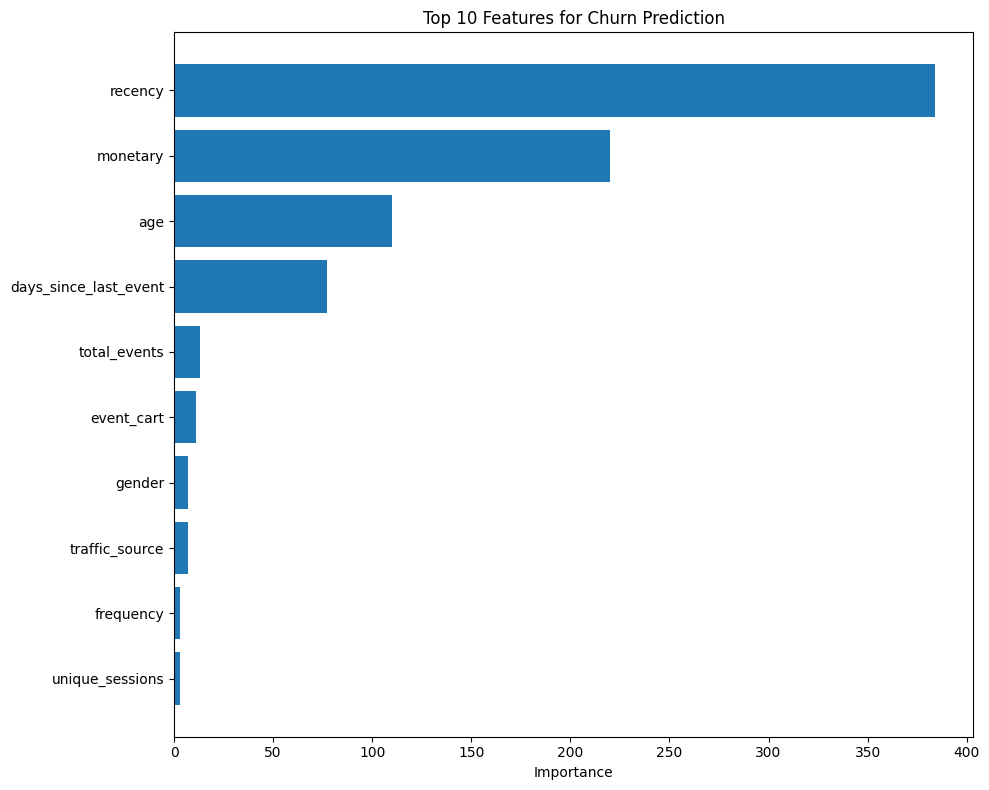


КЛЮЧЕВЫЕ ТРИГГЕРЫ ОТТОКА (для бизнес-выводов)
1. recency: 384
2. monetary: 220
3. age: 110
4. days_since_last_event: 77
5. total_events: 13


In [22]:
# Важность признаков
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*50)
print("ТОП-15 ВАЖНЕЙШИХ ПРИЗНАКОВ ДЛЯ ПРОГНОЗА ОТТОКА")
print("="*50)
print(feature_importance.head(15).to_string(index=False))

# Визуализация
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(10)['feature'], feature_importance.head(10)['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Features for Churn Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()

# Анализ триггеров оттока
print("\n" + "="*50)
print("КЛЮЧЕВЫЕ ТРИГГЕРЫ ОТТОКА (для бизнес-выводов)")
print("="*50)

top_features = feature_importance.head(5)['feature'].values
for i, feat in enumerate(top_features, 1):
    importance_val = feature_importance[feature_importance['feature'] == feat]['importance'].values[0]
    print(f"{i}. {feat}: {importance_val:.0f}")

In [23]:
print("\n" + "="*50)
print("СРАВНЕНИЕ ОТТОЧНЫХ VS ЛОЯЛЬНЫХ КЛИЕНТОВ")
print("="*50)

churned = df_model[df_model['churn'] == 1]
loyal = df_model[df_model['churn'] == 0]

# Выбираем важные признаки для анализа
analysis_cols = ['recency', 'frequency', 'monetary', 'total_events',
                 'days_since_last_event', 'age', 'return_rate']

for col in analysis_cols:
    if col in df_model.columns:
        churn_mean = churned[col].mean()
        loyal_mean = loyal[col].mean()
        diff_pct = ((churn_mean - loyal_mean) / loyal_mean * 100) if loyal_mean != 0 else 0

        print(f"\n{col}:")
        print(f"  Отток (среднее): {churn_mean:.2f}")
        print(f"  Лояльные (среднее): {loyal_mean:.2f}")
        print(f"  Разница: {diff_pct:+.1f}%")

# Дополнительно: распределение по трафику
print("\n" + "="*50)
print("РАСПРЕДЕЛЕНИЕ ПО TRAFFIC_SOURCE")
print("="*50)
traffic_churn = df_model.groupby('traffic_source')['churn'].agg(['mean', 'count'])
traffic_churn = traffic_churn.sort_values('mean', ascending=False)
print(traffic_churn.head(10))


СРАВНЕНИЕ ОТТОЧНЫХ VS ЛОЯЛЬНЫХ КЛИЕНТОВ

recency:
  Отток (среднее): 925.11
  Лояльные (среднее): 39.76
  Разница: +2226.9%

frequency:
  Отток (среднее): 0.34
  Лояльные (среднее): 1.20
  Разница: -71.9%

monetary:
  Отток (среднее): 82.41
  Лояльные (среднее): 291.38
  Разница: -71.7%

total_events:
  Отток (среднее): 11.97
  Лояльные (среднее): 41.43
  Разница: -71.1%

days_since_last_event:
  Отток (среднее): 880.36
  Лояльные (среднее): 35.69
  Разница: +2366.9%

age:
  Отток (среднее): 41.15
  Лояльные (среднее): 41.02
  Разница: +0.3%

return_rate:
  Отток (среднее): 0.04
  Лояльные (среднее): 0.16
  Разница: -71.7%

РАСПРЕДЕЛЕНИЕ ПО TRAFFIC_SOURCE
                    mean  count
traffic_source                 
5               1.000000    664
4               0.946692  55564
1               0.946278   3909
3               0.945438  11913
2               0.944950   4723
0               0.940271   3248
